# Coupled HPP and wind farm operation including emissions displacement

This tutorial evaluates the scaled Hollandse Kust Noord (HKN) plant with three policies:

1. **No Yaw** keeps all turbines aligned with the wind.
2. **Optimal Yaw** always applies the precomputed `design_friendly` GNN angles.
3. **Smart Yaw** lets the mixed-integer EMS select the GNN angles hour by hour.
.

## Assembly diagrams

![XDSM of the coupled HKN GNN-loads assembly](../_static/xdsm_coupled_hpp_gnn_loads.svg)

The yellow metamodel block is evaluated before the HPP model to create the compact yaw lookup table. Scalar values use capital abbreviations; `_y` denotes an hourly representative-year vector and `_l` an hourly lifetime vector.

In [1]:
# Install hydesign if needed
import importlib
if not importlib.util.find_spec("hydesign"):
    !pip install git+https://gitlab.windenergy.dtu.dk/TOPFARM/hydesign.git

In [2]:
# The coupled model has optional GNN, PyWake and load-surrogate dependencies.
required = ["design_friendly", "py_wake", "costmodels"]
if any(not importlib.util.find_spec(package) for package in required):
    %pip install "hydesign[gnn-loads] @ git+https://gitlab.windenergy.dtu.dk/TOPFARM/hydesign.git

## What is coupled?

The GNN supplies one optimized yaw state for each wind direction and speed.
PyWake maps the zero-yaw and optimized-yaw states to HKN power, while turbine
load surrogates and the SUDOCO Variable OPEX Model translate their fatigue-load
difference into an hourly operating cost. The EMS then uses one binary variable
per hour, denoted "smart yaw" to choose between the two states.

The Dutch wind Marginal Displacement Factor (MDF) is included as a time-varying
environmental value in that same objective. It is deliberately kept secondary
here: our main comparison is the performance of the three yaw policies.

In [3]:
%matplotlib inline
from contextlib import redirect_stderr, redirect_stdout
from pathlib import Path
from tempfile import TemporaryDirectory
import io
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull

import hydesign
from design_friendly.utils.easy import easy_yaw_gnn
from design_friendly.utils.get_flowmodel import get_flowmodel
from design_friendly.utils.iea22s import IEA22s
from hydesign.assembly.hpp_pywake_gnn_loads import hpp_model
from py_wake.examples.data.dtu10mw_surrogate import DTU10MW_1WT_Surrogate

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True})
example_root = Path(hydesign.__file__).resolve().parent / "examples"
layout = pd.read_csv(example_root / "SUDOCO" / "hkn_layout.csv")
x, y = layout.x_m.to_numpy(), layout.y_m.to_numpy()
n_wt = len(layout)
print(f"HKN layout: {n_wt} turbines, {22 * n_wt:,.0f} MW installed")

INFO:2026-08-13 12:06:03,668:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.


INFO:jax._src.xla_bridge: Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.


HKN layout: 69 turbines, 1,518 MW installed


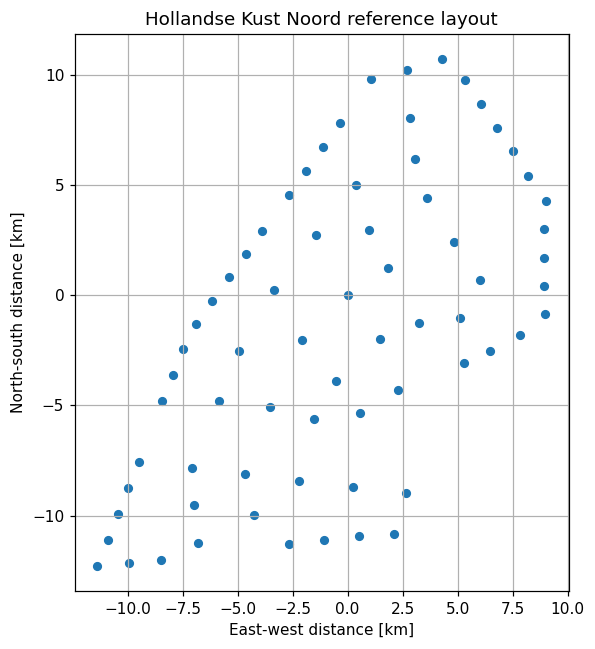

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x / 1000, y / 1000, s=25)
ax.set(xlabel="East-west distance [km]", ylabel="North-south distance [km]",
       title="Hollandse Kust Noord reference layout")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

## 1. Precompute the design-friendly yaw table

The GNN is evaluated once on 2-degree wind-direction bins and wind speeds
from 3 to 24 m/s. `hpp_model.evaluate(...)` later interpolates this table to
the HKN weather time series. The full-year HKN data are bundled with HyDesign;
we select one reproducible week per season to keep this tutorial near five
minutes on a laptop.

In [5]:
wind_directions = np.arange(0, 360, 2)
wind_speeds = np.arange(3, 25)
turbulence_intensity = 0.06

tic = time.perf_counter()
with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    yaw_table = easy_yaw_gnn(
        x, y, wd=wind_directions, ws=wind_speeds, TI=turbulence_intensity
    )
print(f"GNN table shape: {yaw_table.shape}; computed in {time.perf_counter() - tic:.1f} s")

INFO:design_friendly.utils.to_graph: generated 3960 graphs from 3960 cases


'generate_graphs // n=1 // 8.331 s // total=8 s'

'graph_maker_lut // n=1 // 8.362 s // total=8 s'

'predict_torchscript // n=1 // 58.326 s // total=58 s'

'torchscript_to_lut // n=1 // 0.018 s // total=0 s'

'easy_yaw_gnn // n=1 // 66.797 s // total=67 s'

GNN table shape: (69, 180, 22); computed in 66.8 s


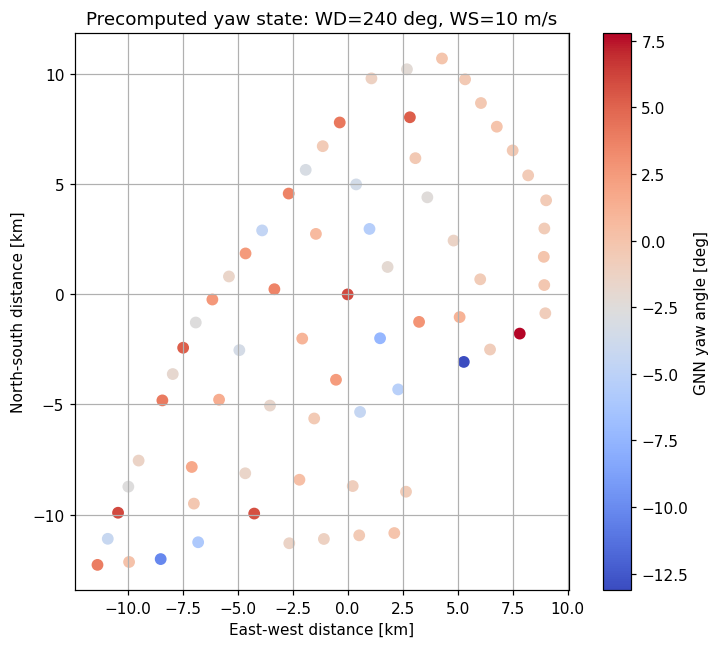

In [6]:
wd_to_show, ws_to_show = 240, 10
yaw_snapshot = yaw_table[:, wd_to_show // 2, ws_to_show - 3]
fig, ax = plt.subplots(figsize=(7, 6))
points = ax.scatter(x / 1000, y / 1000, c=yaw_snapshot, cmap="coolwarm", s=45)
fig.colorbar(points, ax=ax, label="GNN yaw angle [deg]")
ax.set(xlabel="East-west distance [km]", ylabel="North-south distance [km]",
       title=f"Precomputed yaw state: WD={wd_to_show} deg, WS={ws_to_show} m/s")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

## 2. Build and evaluate complete HPP models

Only `yaw_mode` changes between the three objects. `reference` fixes the EMS
binary to zero, `controlled` fixes it to one, and `smart` lets the EMS choose.

In [7]:
rotor_diameter = 284.0
hub_height = 170.0
rated_power = 22.0
area_km2 = ConvexHull(np.column_stack([x, y])).volume / 1e6
wind_density = n_wt * rated_power / area_km2
n_selected_hours = 4 * 7 * 24

farm = get_flowmodel(wt=IEA22s())
farm_load = get_flowmodel(wt=DTU10MW_1WT_Surrogate())
temporary_workdir = TemporaryDirectory(prefix="hydesign_hkn_")

model_options = dict(
    n_wt=n_wt, farm=farm, farm_load=farm_load,
    latitude=52.6977727, longitude=4.293496346, altitude=1.0,
    sim_pars_fn=str(example_root / "Europe" / "hpp_pars.yml"),
    input_ts_fn=str(example_root / "Europe" / "GWA2" / "input_ts_HKN.csv"),
    MDF_fn=str(example_root / "Europe" / "df_mdf_wind_nl_20251219_1451_[2023, 2024].csv"),
    emissions_value=100.0,              # EUR/tCO2e in the EMS objective
    weeks_per_season_per_year=1, seed=0,
    ems_batch_size=72, intervals_per_hour=1,
    x=x, y=y, tilt=np.zeros(n_selected_hours),
    time_stamp=np.arange(n_selected_hours),
    G_MW=0.9 * n_wt * rated_power, TI=turbulence_intensity,
    work_dir=temporary_workdir.name, verbose=False,
)

design = dict(
    clearance=hub_height - rotor_diameter / 2,
    sp=rated_power * 1e6 / (np.pi * rotor_diameter**2 / 4),
    p_rated=rated_power, Nwt=n_wt,
    wind_MW_per_km2=wind_density,
    solar_MW=0.0, surface_tilt=30.0, surface_azimuth=180.0, DC_AC_ratio=1.0,
    b_P=0.2 * n_wt * rated_power, b_E_h=4.0,
    cost_of_battery_P_fluct_in_peak_price_ratio=0.0,
    yaw=yaw_table,
)

C:\Users\mikf\Anaconda3\envs\hydesign2\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


C:\Users\mikf\Anaconda3\envs\hydesign2\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [8]:
yaw_modes = {
    "No Yaw": "reference",
    "Optimal Yaw": "controlled",
    "Smart Yaw": "smart",
}
hpp_models, hpp_outputs = {}, {}

tic = time.perf_counter()
for label, yaw_mode in yaw_modes.items():
    print(f"Evaluating {label} ...")
    # Suppress detailed PyWake/load progress while retaining the simple status above.
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        hpp = hpp_model(yaw_mode=yaw_mode, **model_options)
        outputs = hpp.evaluate(**design)
    hpp_models[label] = hpp
    hpp_outputs[label] = dict(zip(hpp.list_out_vars, outputs))

print(f"Finished three complete HPP evaluations in {(time.perf_counter() - tic) / 60:.1f} min")

Evaluating No Yaw ...


Evaluating Optimal Yaw ...


Evaluating Smart Yaw ...


Finished three complete HPP evaluations in 4.6 min


## 3. Extract results from the HPP objects

Every plotted signal comes from `hpp.prob` or the values returned by
`hpp.evaluate`. For example, `lambda_t` is the yaw-state decision, `M` is the
hourly load-related cost supplied to the EMS, `LDEL` is the resulting lifetime
equivalent load, and `hpp_t` is plant export.

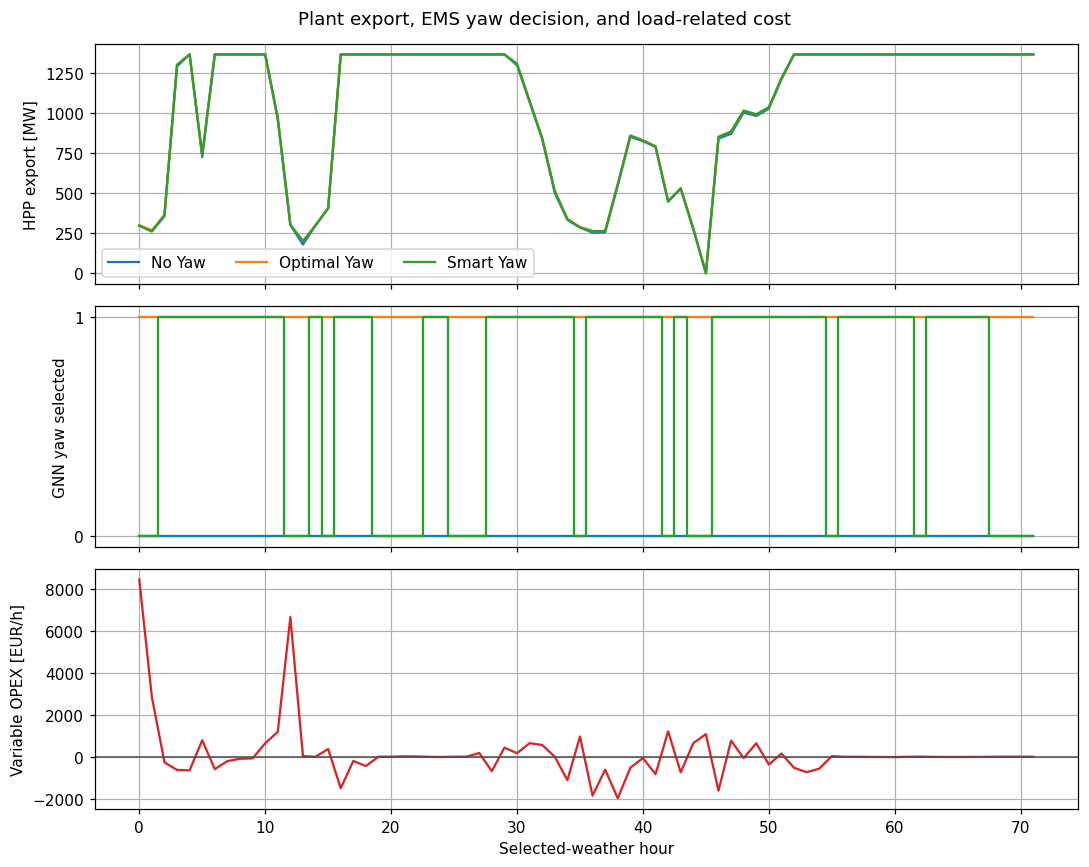

In [9]:
zoom = slice(0, 72)
hours = np.arange(72)
smart = hpp_models["Smart Yaw"].prob

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for label, hpp in hpp_models.items():
    axes[0].plot(hours, hpp.prob.get_val("hpp_t")[zoom], label=label)
axes[0].set_ylabel("HPP export [MW]")
axes[0].legend(ncol=3)

for label, hpp in hpp_models.items():
    axes[1].step(hours, hpp.prob.get_val("lambda_t")[zoom], where="mid", label=label)
axes[1].set_ylabel("GNN yaw selected")
axes[1].set_yticks([0, 1])

axes[2].plot(hours, smart.get_val("M")[zoom], color="tab:red")
axes[2].axhline(0, color="0.3", linewidth=1)
axes[2].set(xlabel="Selected-weather hour", ylabel="Variable OPEX [EUR/h]")
fig.suptitle("Plant export, EMS yaw decision, and load-related cost")
fig.tight_layout()
plt.show()

The MDF values below are read by each complete HPP object and passed to
its EMS component. Following Kainz et al., the wind MDF represents the
time-varying power-system emissions displaced by incremental wind generation:
S. Kainz et al. (2025), *An initial study on the environmental value of wind
farm control*, J. Phys.: Conf. Ser. 3131 012044,
[doi:10.1088/1742-6596/3131/1/012044](https://doi.org/10.1088/1742-6596/3131/1/012044).

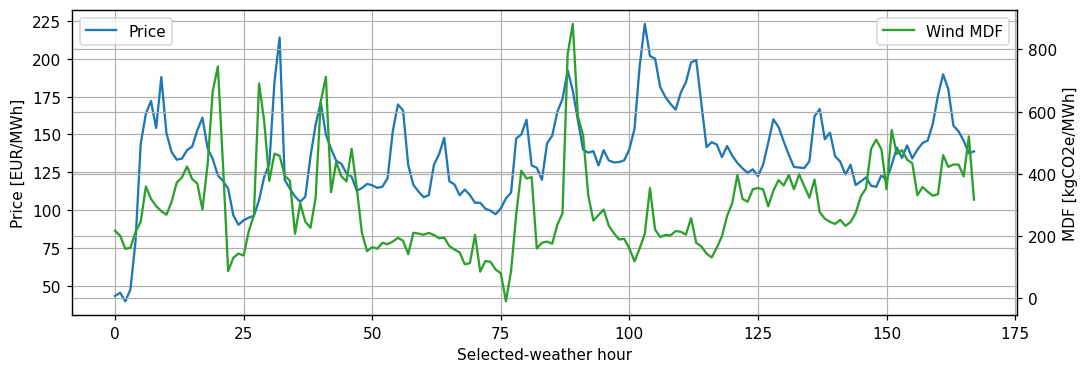

In [10]:
fig, price_axis = plt.subplots(figsize=(10, 3.5))
mdf_axis = price_axis.twinx()
price_axis.plot(np.arange(168), smart.get_val("price_t")[:168], color="tab:blue", label="Price")
mdf_axis.plot(np.arange(168), smart.get_val("marginal_displacement_factor_t")[:168],
              color="tab:green", label="Wind MDF")
price_axis.set(xlabel="Selected-weather hour", ylabel="Price [EUR/MWh]")
mdf_axis.set_ylabel("MDF [kgCO2e/MWh]")
price_axis.legend(loc="upper left")
mdf_axis.legend(loc="upper right")
fig.tight_layout()
plt.show()

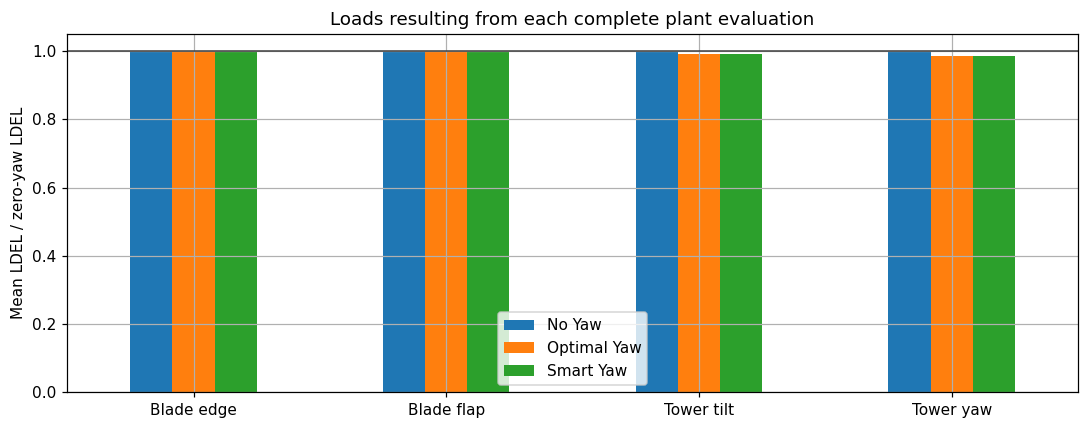

In [11]:
sensor_names = ["Blade edge", "Blade flap", "Tower tilt", "Tower yaw"]
load_ratio = pd.DataFrame({
    label: (hpp.prob.get_val("LDEL") / hpp.prob.get_val("LDEL_ref")).mean(axis=1)
    for label, hpp in hpp_models.items()
}, index=sensor_names)

ax = load_ratio.plot(kind="bar", figsize=(10, 4), rot=0)
ax.axhline(1, color="0.25", linewidth=1)
ax.set(ylabel="Mean LDEL / zero-yaw LDEL",
       title="Loads resulting from each complete plant evaluation")
fig = ax.get_figure()
fig.tight_layout()
plt.show()

## 4. Compare plant performance

The selected seasonal weeks are expanded by HyDesign to a representative year.
The **coupled operating score** below is the EMS objective's energy terms:

`electricity revenue + displaced-emissions value - yaw-related Variable OPEX`

Smart Yaw can choose either fixed policy in every hour, so it gives the highest
coupled score. Optimal Yaw can still produce the most energy; Smart Yaw's
advantage is avoiding the hours where that extra energy is not worth its
concurrent load and system value.

In [12]:
def annualize_selected_weeks(values):
    # Expand four selected weeks over their real meteorological months.
    djf, mam, jja, son = np.split(np.asarray(values), 4)
    repeat_to = lambda week, hours: np.resize(week, hours)
    winter = repeat_to(djf, 90 * 24)
    return np.concatenate([
        winter[31 * 24:], repeat_to(mam, 92 * 24),
        repeat_to(jja, 92 * 24), repeat_to(son, 91 * 24),
        winter[:31 * 24],
    ])

def summarize_hpp(label, hpp):
    prob = hpp.prob
    export = prob.get_val("hpp_t")[:8760]
    price = prob.get_val("price_t_ext")[:8760]
    selected = annualize_selected_weeks(prob.get_val("lambda_t"))
    variable_opex = annualize_selected_weeks(prob.get_val("M"))
    mdf = annualize_selected_weeks(prob.get_val("marginal_displacement_factor_t"))
    revenue = np.sum(price * export)
    load_cost = np.sum(selected * variable_opex)
    displaced = np.sum(mdf * export) / 1000  # tCO2e
    coupled_score = revenue - load_cost + model_options["emissions_value"] * displaced
    return pd.Series({
        "AEP [GWh]": hpp_outputs[label]["AEP [GWh]"],
        "electricity revenue [MEUR/y]": revenue / 1e6,
        "yaw Variable OPEX [MEUR/y]": load_cost / 1e6,
        "emissions displaced [ktCO2e/y]": displaced / 1000,
        "coupled operating score [MEUR/y]": coupled_score / 1e6,
        "selected yaw hours [four weeks]": prob.get_val("lambda_t").sum(),
    })

performance = pd.DataFrame({
    label: summarize_hpp(label, hpp) for label, hpp in hpp_models.items()
})
performance.round(2)

,No Yaw,Optimal Yaw,Smart Yaw
AEP [GWh],6884.32,6913.03,6911.36
electricity revenue [MEUR/y],626.14,629.11,628.73
yaw Variable OPEX [MEUR/y],0.00,0.08,-2.39
emissions displaced [ktCO2e/y],1294.19,1299.92,1299.07
coupled operating score [MEUR/y],755.55,759.02,761.03
selected yaw hours [four weeks],0.00,672.00,473.00


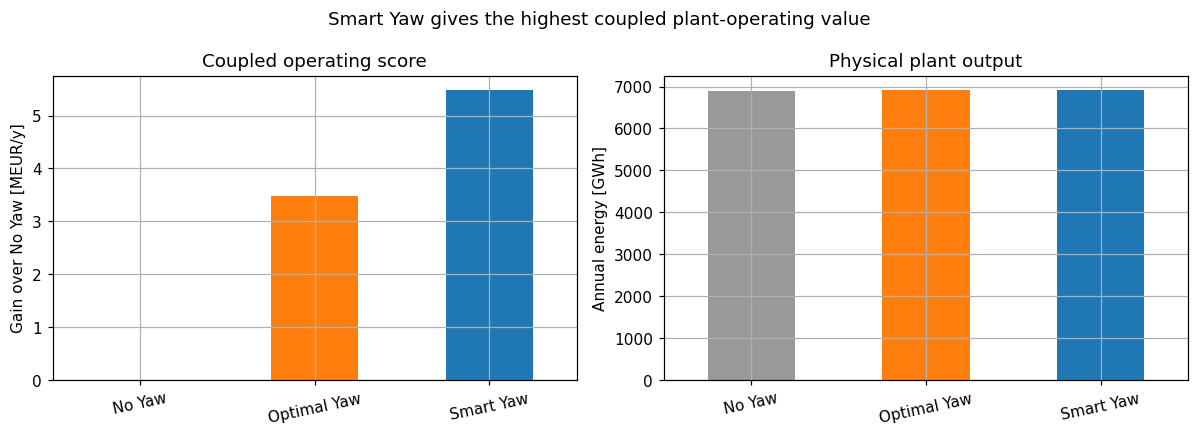

In [13]:
baseline = performance["No Yaw"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

score_gain = performance.loc["coupled operating score [MEUR/y]"] - baseline.loc[
    "coupled operating score [MEUR/y]"
]
score_gain.plot(kind="bar", ax=axes[0], color=["0.6", "tab:orange", "tab:blue"], rot=12)
axes[0].set(ylabel="Gain over No Yaw [MEUR/y]", title="Coupled operating score")

performance.loc["AEP [GWh]"].plot(
    kind="bar", ax=axes[1], color=["0.6", "tab:orange", "tab:blue"], rot=12
)
axes[1].set(ylabel="Annual energy [GWh]", title="Physical plant output")
fig.suptitle("Smart Yaw gives the highest coupled plant-operating value")
fig.tight_layout()
plt.show()

## Takeaways

- The tutorial runs three complete `hpp_pywake_gnn_loads.hpp_model` objects;
  nothing is dispatched by calling an EMS function from the notebook.
- Optimal Yaw applies the GNN table in every hour and maximizes physical energy.
- Smart Yaw uses the same table selectively and maximizes the coupled operating
  value once electricity, SUDOCO load-related Variable OPEX, plant constraints,
  and the Dutch MDF are considered together.
- Try changing `emissions_value`, the battery size, or
  `weeks_per_season_per_year`. Setting the latter to `None` runs all 8,760 HKN
  weather hours and is appropriate for a research run rather than a tutorial.